In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'c:\Users\lucat\SkadiAI\.venv\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)


In [ ]:
path = "C:/Users/lucat/skadiAI/data/20180808T075536_dmi_prep.nc"   # metti il nome di uno dei tuoi file
ds = xr.open_dataset(path, engine="h5netcdf")
ds

<xarray.Dataset> Size: 119MB
Dimensions:               (sar_lines: 1200, sar_samples: 5185,
                           sar_sample_2dgrid_points: 6,
                           sar_line_2dgrid_points: 21, 2km_grid_lines: 48,
                           2km_grid_samples: 207)
Dimensions without coordinates: sar_lines, sar_samples,
                                sar_sample_2dgrid_points,
                                sar_line_2dgrid_points, 2km_grid_lines,
                                2km_grid_samples
Data variables: (12/29)
    SIC                   (sar_lines, sar_samples) uint8 6MB ...
    SOD                   (sar_lines, sar_samples) uint8 6MB ...
    FLOE                  (sar_lines, sar_samples) uint8 6MB ...
    sar_grid2d_latitude   (sar_sample_2dgrid_points, sar_line_2dgrid_points) float64 1kB ...
    sar_grid2d_longitude  (sar_sample_2dgrid_points, sar_line_2dgrid_points) float64 1kB ...
    nersc_sar_primary     (sar_lines, sar_samples) float32 25MB ...
    ...                    ...
    u10m_rotated          (2km_grid_lines, 2km_grid_samples) float32 40kB ...
    v10m_rotated          (2km_grid_lines, 2km_grid_samples) float32 40kB ...
    t2m                   (2km_grid_lines, 2km_grid_samples) float32 40kB ...
    skt                   (2km_grid_lines, 2km_grid_samples) float32 40kB ...
    tcwv                  (2km_grid_lines, 2km_grid_samples) float32 40kB ...
    tclw                  (2km_grid_lines, 2km_grid_samples) float32 40kB ...
Attributes:
    scene_id:       20180213T202018_dmi_prep.nc
    original_id:    S1A_EW_GRDM_1SDH_20180213T202018_20180213T202033_020593_0...
    ice_service:    dmi
    flip:           0
    pixel_spacing:  80

In [23]:
def mostra_scena(path):

    ds = xr.open_dataset(path)

    fig.suptitle(path)
    fig, axes = plt.subplots(4, 1, figsize=(18, 17))

    sod = ds["SOD"].values
    sod_vis = np.ma.masked_equal(sod, 255)   # nasconde i pixel che valgono 255
    sic = ds["SIC"].values
    sic_vis = np.ma.masked_equal(sic, 255)

    axes[0].imshow(ds["nersc_sar_primary"].values, cmap="gray")
    axes[1].imshow(ds["nersc_sar_secondary"].values, cmap="gray")
    im1 = axes[2].imshow(sod_vis, vmin=-0.5, vmax=5.5, cmap=plt.get_cmap("tab10", 6))
    fig.colorbar(im1, ax=axes[2])
    im2 = axes[3].imshow(sic_vis, cmap="Blues_r")
    fig.colorbar(im2, ax=axes[3])


    axes[0].set_title("HH")
    axes[1].set_title("HV")
    axes[2].set_title("SOD")
    axes[3].set_title("SIC")

    axes[2].set_facecolor("lightgrey")
    axes[3].set_facecolor("lightgrey")

    plt.show()



In [24]:
esempio = np.array([0, 0, 3, 255, 5, 255, 0, 0])

maschera = esempio != 255
print(maschera)
print(esempio[maschera])

[ True  True  True False  True False  True  True]
[0 0 3 5 0 0]


In [25]:
def sod_percentages(path):
    ds = xr.open_dataset(path)
    sod = ds["SOD"].values

    valid = sod[sod != 255]            # Step 1: keep only pixels different from 255
    values, counts = np.unique(valid, return_counts=True)     # np.unique on the valid pixels
    percentages = counts / counts.sum() * 100        # Step 2

    return dict(zip(values.tolist(), percentages.round(2).tolist()))

In [ ]:
from pathlib import Path
import pandas as pd             #libreria python per lavorare sulle tabelle

results = {}
for path in sorted(Path("../data").glob("*.nc")):           #trova tutti i file che finiscono in .nc nella cartella "data"
    results[path.name] = sod_percentages(path)


table = pd.DataFrame(results).T.fillna(0)               #pd.DataFrame(...): trasforma tutto in una tabella; T.: inverte righe e colonne; .fillna(0): mette 0 dove una scena non contiene una certa classe
table = table.sort_index(axis=1)
table

,0,1,2,3,4,5
20180213T202018_dmi_prep.nc,99.24,0.00,0.00,0.76,0.00,0.00
20180607T184226_dmi_prep.nc,34.51,0.00,0.00,0.00,65.49,0.00
20180808T075536_dmi_prep.nc,88.77,0.00,0.00,0.00,7.78,3.45
20181104T122313_cis_prep.nc,95.84,4.16,0.00,0.00,0.00,0.00
20190115T104348_cis_prep.nc,6.12,0.00,64.64,29.24,0.00,0.00


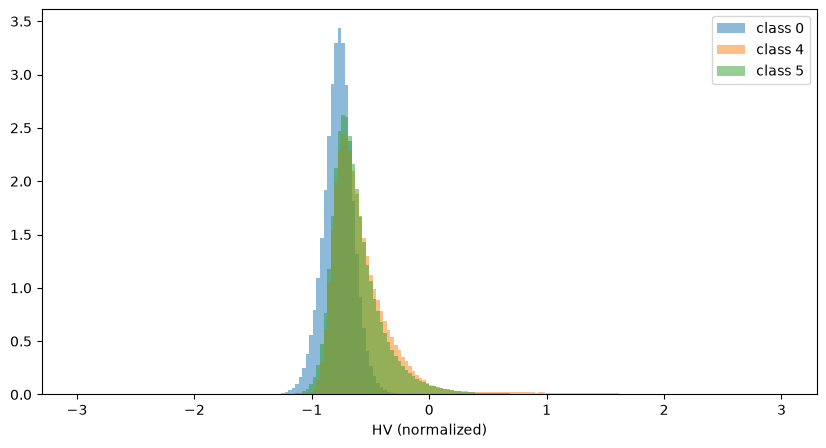

,HH mean,HV mean,pixels
0,-1.412953,-0.771783,14384049.0
4,-1.060490,-0.541926,1260254.0
5,-1.233788,-0.600449,559433.0


In [35]:
def mean_backscatter_per_class(path):
    ds = xr.open_dataset(path)
    hh = ds["nersc_sar_primary"].values
    hv = ds["nersc_sar_secondary"].values
    sod = ds["SOD"].values

    results = {}
    for c in np.unique(sod):           #ripete il blocco una volta per ogni classe presente
        if c == 255:
            continue                 # skip masked pixels
        mask = sod == c                 # True where the pixel belongs to class c
        results[int(c)] = {
            "HH mean": hh[mask].mean(),          # mean of hh on the pixels of class c
            "HV mean": hv[mask].mean(),          # mean of hv on the pixels of class c
            "pixels": mask.sum(),           # how many pixels belong to class c (hint: mask.sum())
        }

    fig, ax = plt.subplots(figsize=(10, 5))
    for c in [0, 4, 5]:
        ax.hist(hv[sod == c], bins=200, range=(-3, 3), density=True, alpha=0.5, label=f"class {c}")
    ax.set_xlabel("HV (normalized)")
    ax.legend()
    plt.show()
    return pd.DataFrame(results).T


mean_backscatter_per_class("../data/20180808T075536_dmi_prep.nc")

